In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('car_data.csv')

In [3]:
print(df.describe())
print(df.info())
print(df.isnull().sum())
print(df.head(10))
print(df.tail(10))

              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3 

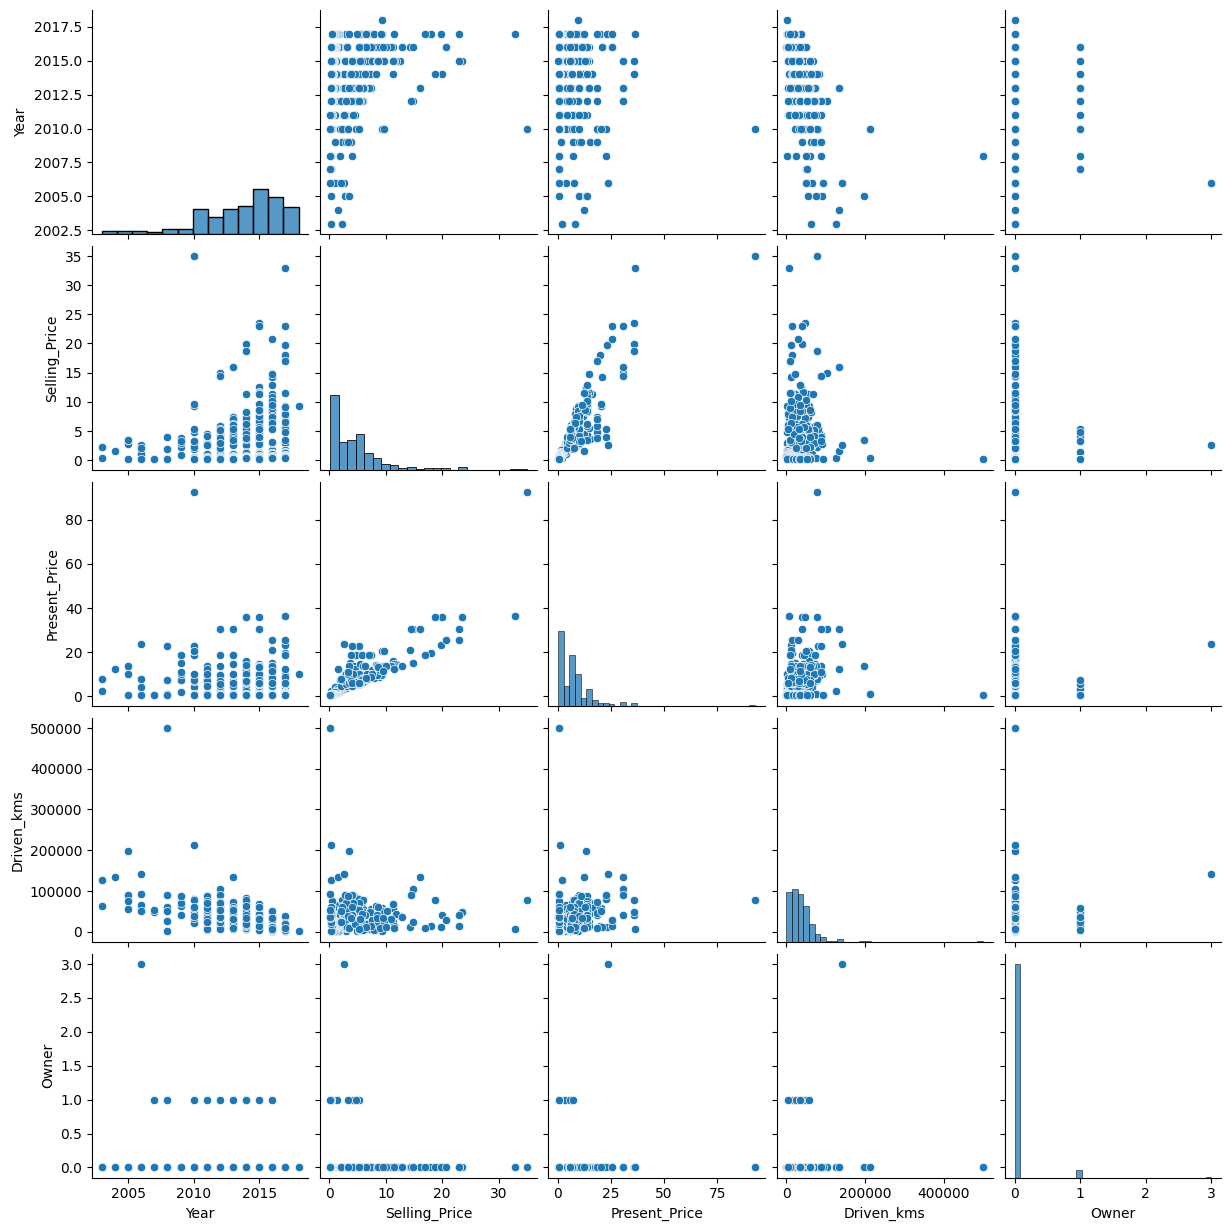

In [4]:
df.columns
sns.pairplot(data = df)

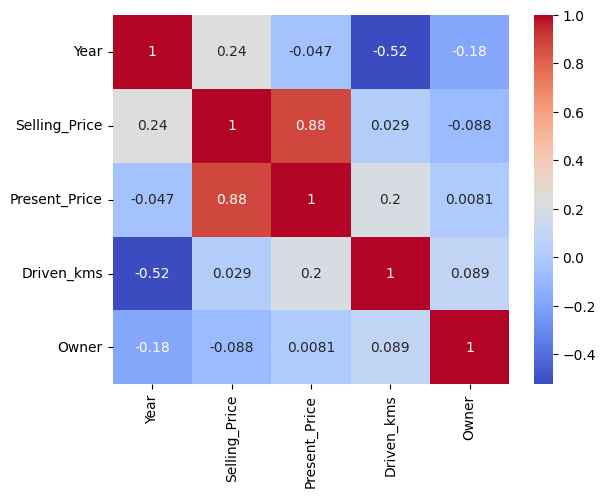

In [5]:
sns.heatmap(df.corr(numeric_only = True),annot = True,cmap = "coolwarm")
plt.show()


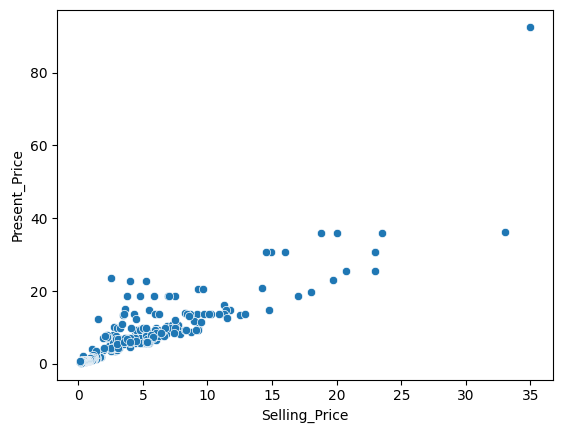

In [6]:
sns.scatterplot(data=df,x="Selling_Price",y="Present_Price")
plt.show()

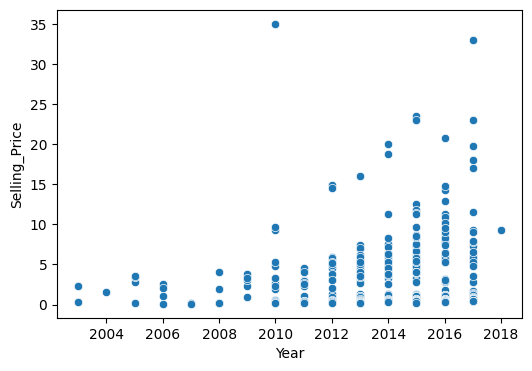

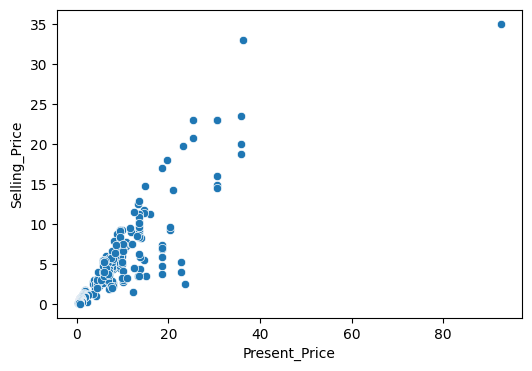

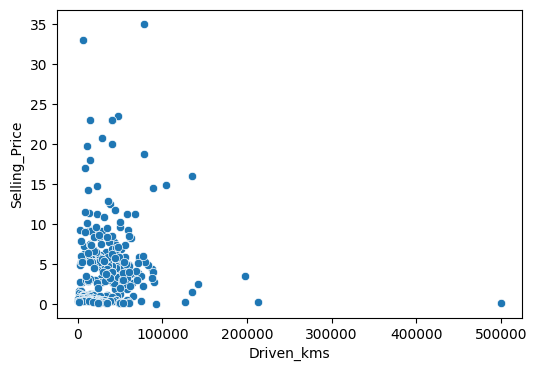

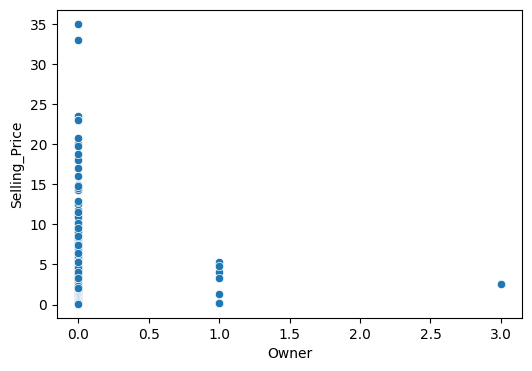

In [7]:
cols = df.select_dtypes(include=["int64","float64"]).columns.drop("Selling_Price")

for col in cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df,x=col,y="Selling_Price")
    plt.show()

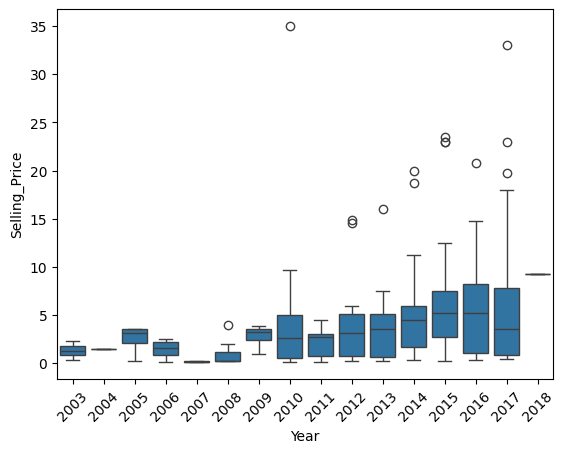

In [8]:
sns.boxplot(data=df,x="Year",y="Selling_Price")
plt.xticks(rotation=45)
plt.show()

In [9]:
df.columns
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


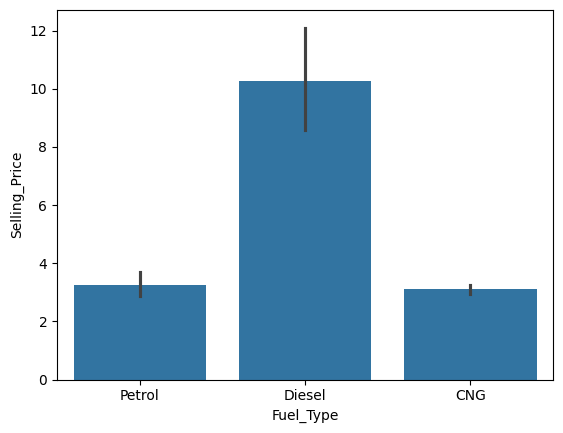

In [10]:
sns.barplot(data=df,x="Fuel_Type",y="Selling_Price")
plt.show()


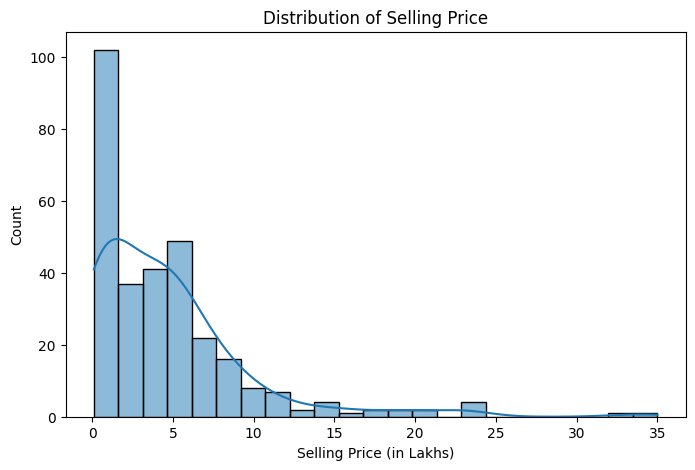

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (in Lakhs)")
plt.ylabel("Count")
plt.show()

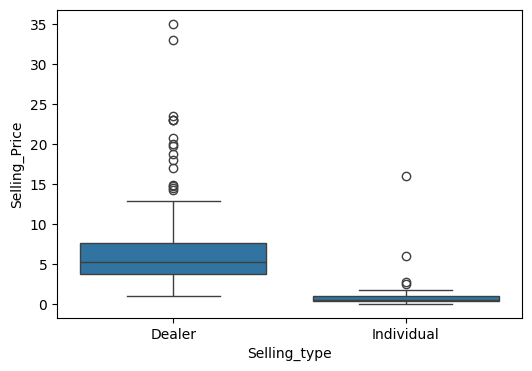

In [12]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Selling_type", y="Selling_Price")
plt.show()

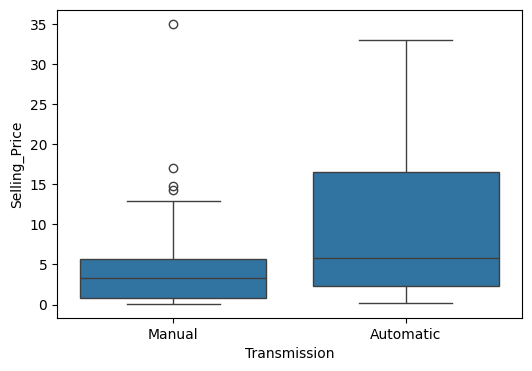

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Transmission", y="Selling_Price")
plt.show()

In [14]:
df = df[df["Driven_kms"] < 300000]

In [15]:
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

In [16]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,0,True,False,False,True
297,brio,2015,4.00,5.90,60000,0,False,True,False,True
298,city,2009,3.35,11.00,87934,0,False,True,False,True
299,city,2017,11.50,12.50,9000,0,True,False,False,True


In [17]:
df["Car_Age"] = 2026 - df["Year"]
df = df.drop("Year",axis=1)

In [18]:
df["Car_Name_Group"] = df["Car_Name"].apply(lambda x: x.split()[0])
df = df.drop("Car_Name", axis=1)

In [19]:
df = pd.get_dummies(df,columns=["Car_Name_Group"],drop_first=True)

In [20]:
X = df.drop("Selling_Price",axis=1)
y = df["Selling_Price"]

In [21]:
X

,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual,Car_Age,Car_Name_Group_Activa,Car_Name_Group_Bajaj,...,Car_Name_Group_land,Car_Name_Group_omni,Car_Name_Group_ritz,Car_Name_Group_s,Car_Name_Group_swift,Car_Name_Group_sx4,Car_Name_Group_verna,Car_Name_Group_vitara,Car_Name_Group_wagon,Car_Name_Group_xcent
0,5.59,27000,0,False,True,False,True,12,False,False,...,False,False,True,False,False,False,False,False,False,False
1,9.54,43000,0,True,False,False,True,13,False,False,...,False,False,False,False,False,True,False,False,False,False
2,9.85,6900,0,False,True,False,True,9,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4.15,5200,0,False,True,False,True,15,False,False,...,False,False,False,False,False,False,False,False,True,False
4,6.87,42450,0,True,False,False,True,12,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,11.60,33988,0,True,False,False,True,10,False,False,...,False,False,False,False,False,False,False,False,False,False
297,5.90,60000,0,False,True,False,True,11,False,False,...,False,False,False,False,False,False,False,False,False,False
298,11.00,87934,0,False,True,False,True,17,False,False,...,False,False,False,False,False,False,False,False,False,False
299,12.50,9000,0,True,False,False,True,9,False,False,...,False,False,False,False,False,False,False,False,False,False


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [24]:
model1 = LinearRegression()
model2 = RandomForestRegressor(n_estimators=100, random_state=42)

In [25]:
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
model2.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [27]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For Random Forest Regression
mae = mean_absolute_error(y_test,y_pred2)
mse = mean_squared_error(y_test,y_pred2)
R2 = r2_score(y_test,y_pred2)

print("MAE : ",mae)
print("MSE : ",mse)
print("R2 Score : ",R2)

MAE :  0.6303600000000001
MSE :  0.8881460440000009
R2 Score :  0.9630439654516971


**Data is not fully linear that's why Linear reression is not have high R2.**

In [29]:
# For Linear Regression

mae1 = mean_absolute_error(y_test,y_pred1)
mse1 = mean_squared_error(y_test,y_pred1)
r2 = r2_score(y_test,y_pred1)
print("MAE : ",mae1)
print("MSE : ",mse1)
print("R2 Score : ",r2)

MAE :  1.2949732804697294
MSE :  3.776381752391094
R2 Score :  0.8428635746882349


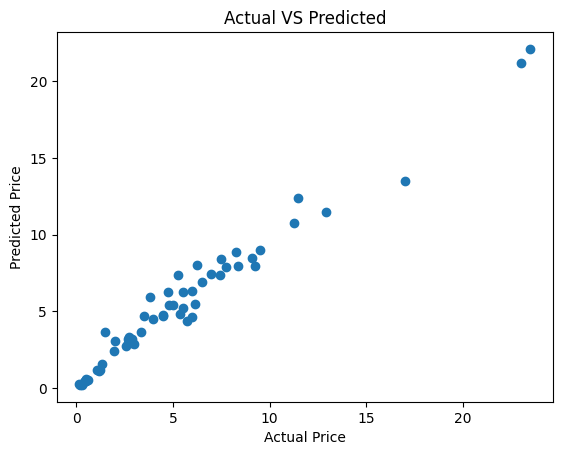

In [30]:
plt.scatter(y_test,y_pred2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual VS Predicted")
plt.show()